# Final methodology for closure strength

This notebook computes closure strength for all 1,627 films in the corpus. The methodology was worked out in `closure-strength.ipynb`, where I tested two candidates: a *level* metric (mean z-score of the final 10%) and a *slope* metric (linear fit over the final 20%). I tested both on Rocky Balboa and No Country for Old Men, and the level version was the clear winner. Slope gave No Country a higher closure score than Rocky, which is backwards. It was rewarding "climbed out of a trough" rather than "landed decisively." Level got it right: Rocky ends high, No Country ends middling.

So this notebook runs the level metric across the full corpus and exports the results. Nothing exploratory here, just the clean production run.

## Section 1: Load arcs

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family'      : 'Baskerville',
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'legend.fontsize'  : 10,
    'figure.titlesize'   : 14,
    'figure.titleweight' : 'bold',
})

ARCS_DIR   = Path('../docs/thesis-outputs/arcs')
OUTPUT_DIR = Path('../docs/thesis-outputs/')

arc_files = sorted(ARCS_DIR.glob('*_arc.json'))
print(f'{len(arc_files)} arc files found')

1627 arc files found


## Section 2: Closure level metric

Each arc file contains a `main_arc` field with 20 z-scored sentiment points at fixed positions from 0.05 to 0.975. The z-scores are already normalised against each film's own mean and standard deviation, so a volatile film and a flat film are on the same scale.

Closure level is the mean z-score of the points inside the final 10% of the arc (positions >= 0.9). If positive, the film ends above its own emotional baseline. If negative, it ends below. Simple as that.

In [2]:
def load_main_arc(path):
    with open(path) as f:
        data = json.load(f)
    pts = data['main_arc']
    pos = np.array([p['position'] for p in pts])
    z   = np.array([p['z_score']  for p in pts])
    return data, pos, z


def closure_level(pos, z, window=0.10):
    """Mean z-score inside the final `window` of the arc."""
    mask = pos >= (1.0 - window)
    return float(z[mask].mean()) if mask.any() else np.nan

## Section 3: Compute across all films

In [3]:
rows = []
for path in arc_files:
    try:
        data, pos, z = load_main_arc(path)
    except Exception as e:
        print(f'skip {path.name}: {e}')
        continue
    rows.append({
        'slug':          data.get('slug', path.stem.replace('_arc', '')),
        'title':         data.get('title'),
        'year':          data.get('year'),
        'closure_level': closure_level(pos, z),
    })

closure = pd.DataFrame(rows)
print(f'{len(closure)} films computed')
closure.describe()

1627 films computed


,year,closure_level
count,1627.000000,1627.000000
mean,2006.708666,0.631491
std,12.421213,0.888897
min,1980.000000,-2.242036
25%,1996.500000,0.060840
50%,2010.000000,0.732977
75%,2017.000000,1.300148
max,2025.000000,2.581790


## Section 4: Distribution

Quick look at how closure level is distributed across the corpus. If the Hollywood ending instinct is real, most of this histogram should sit to the right of zero.

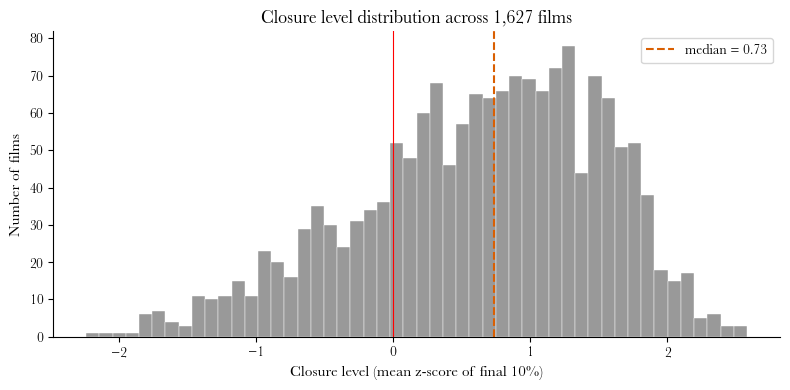

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(closure['closure_level'].dropna(), bins=50, color='#999999', edgecolor='white', lw=0.3)
ax.axvline(0, color='red', lw=0.8)
ax.axvline(closure['closure_level'].median(), color='#D95F02', lw=1.5, ls='--',
           label=f"median = {closure['closure_level'].median():.2f}")
ax.set_xlabel('Closure level (mean z-score of final 10%)')
ax.set_ylabel('Number of films')
ax.set_title('Closure level distribution across 1,627 films')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/closure_level_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Interesting. I can see that most films end on a higher emotional note than their own average. The median sits at +0.73, which means the typical film in this corpus finishes noticeably above its own baseline mood. I wouldn't call this subtle. The bulk of the histogram clusters between +0.5 and +1.5, which tells me there's something like a default Hollywood instinct to resolve upward, and most films land in a pretty similar range when they do it. But there's a real tail on the left side. A few hundred films end below their own baseline, and they stretch further into negative territory than the positive side stretches into positive. So films that end high tend to end in a similar band, but films that end low vary a lot more in just how far down they're willing to go. The ceiling for euphoric endings is tighter than the floor for bleak ones.

## Section 5: Extremes

The films at the top and bottom of the closure level ranking. This is the face-validity test. If I recognise the top as films that end on a genuine emotional high and the bottom as films that end cold or unresolved, the metric is working.

In [5]:
print('Highest closure level')
print(closure.nlargest(15, 'closure_level')[['title', 'year', 'closure_level']].to_string(index=False))
print()
print('Lowest closure level')
print(closure.nsmallest(15, 'closure_level')[['title', 'year', 'closure_level']].to_string(index=False))

Highest closure level
                               title  year  closure_level
                No One Will Save You  2023       2.581790
                         Chasing Amy  1997       2.577878
                  The Breakfast Club  1985       2.516631
                              Fences  2016       2.451048
                    Any Given Sunday  1999       2.433667
                           Nine Days  2020       2.430665
                                  It  2017       2.341758
National Lampoons Christmas Vacation  1989       2.336172
                            Sleepers  1996       2.330870
Harry Potter And The Sorcerers Stone  2001       2.309395
                          Paranorman  2012       2.302556
                 Lucky Number Slevin  2006       2.296693
                           Emergency  2022       2.272157
                      My Demon Lover  1987       2.242514
                          Four Rooms  1995       2.210235

Lowest closure level
                         tit

## Section 6: Export

Writing out to CSV so I can join this with the rest of the per-film features later.

In [6]:
out_path = OUTPUT_DIR / 'closure_strength.csv'
closure.to_csv(out_path, index=False)
print(f'Wrote {out_path}  ({len(closure)} rows)')

Wrote ../docs/thesis-outputs/closure_strength.csv  (1627 rows)
